# V8 — 滚动窗口样本外回测 + 并行算力压榨

真正的量化回测**不能**一次性把未来 48 小时的真值喂给引擎。本 notebook 模拟现实：

1. 站在 $T_0$ 时刻，引擎只看到未来 24h 的**预测**，求解并执行 **1 小时**；
2. 时间推进到 $T_1$，更新信息，再次滚动求解（携带电池真实 SoC 状态）。

由于预测存在误差，滚动策略的**真实兑现成本**必然高于"上帝视角"完美预测——二者之差即 **regret（预测误差的代价）**。最后用 `joblib` 多核并行扫描容量网格，演示算力压榨。

In [1]:
import sys
import time
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

from ecogrid import (
                     GridConfig,
                     MilpDispatchEngine,
                     PlantConfig,
                     ScenarioConfig,
                     generate_scenarios,
                     rolling_backtest,
                     scan_capacities,
)

plt.rcParams["figure.dpi"] = 110
plt.style.use("dark_background")

# ---- 48 小时预测基线 ----
H = 48
hours = np.arange(H)
day = hours % 24
demand = 90 + 45 * np.exp(-((day - 19) ** 2) / 7) - 25 * np.exp(-((day - 12) ** 2) / 9)
solar_fc = np.clip(60 * np.exp(-((day - 12.5) ** 2) / 10), 0, 55)
wind_fc = np.clip(30 + 15 * np.cos(day / 24 * 2 * np.pi + 3.0), 0, 45)

# ---- '真实'天气：在预测上叠加一条 AR(1) 误差实现路径 ----
plant = PlantConfig(wind_capacity=45.0, solar_capacity=55.0)
real = generate_scenarios(wind_fc, solar_fc,
                          ScenarioConfig(n_scenarios=1, ar_coefficient=0.8,
                                         wind_sigma=0.25, solar_sigma=0.30, seed=2024),
                          plant=plant)
wind_actual = real.wind[0]
solar_actual = real.solar[0]
print("预测 vs 真实 风电 MAE:", round(np.mean(np.abs(wind_fc - wind_actual)), 2), "MW")
print("预测 vs 真实 光伏 MAE:", round(np.mean(np.abs(solar_fc - solar_actual)), 2), "MW")

预测 vs 真实 风电 MAE: 3.86 MW
预测 vs 真实 光伏 MAE: 1.78 MW


In [2]:
# ---- 滚动回测：每步只看 24h 预测，执行 1h ----
cfg = GridConfig(carbon_tax_rate=100.0, bess_capacity=100.0, coal_pmin=20.0,
                 coal_pmax=300.0, startup_cost=1500.0, min_up_time=3, min_down_time=2)

bt = rolling_backtest(demand, wind_actual, solar_actual, wind_fc, solar_fc,
                      cfg, lookahead=24, step=1)

# 完美预测基准（上帝视角，一次性求解真值）
perfect = MilpDispatchEngine(cfg).solve(demand, wind_actual, solar_actual)

print(f"滚动真实成本   = €{bt.realized_cost:,.1f}")
print(f"完美预测成本   = €{bt.perfect_cost:,.1f}")
print(f"Regret(误差代价) = €{bt.regret:,.1f}  ({bt.regret / bt.perfect_cost:.1%})")
print(f"未满足电量     = {bt.unmet_energy:.1f} MWh")

滚动真实成本   = €277,863.1
完美预测成本   = €273,572.2
Regret(误差代价) = €4,290.9  (1.6%)
未满足电量     = 0.0 MWh


C:\Users\Averyhong\AppData\Local\Temp\ipykernel_18824\798185533.py:23: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Averyhong\AppData\Local\Temp\ipykernel_18824\798185533.py:23: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Averyhong\AppData\Local\Temp\ipykernel_18824\798185533.py:23: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Averyhong\AppData\Local\Temp\ipykernel_18824\798185533.py:23: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Averyhong\AppData\Local\Temp\ipykernel_18824\798185533.py:23: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Averyhong\AppData\Local\Temp\ipykernel_18824\798185533.py:23: UserWarni

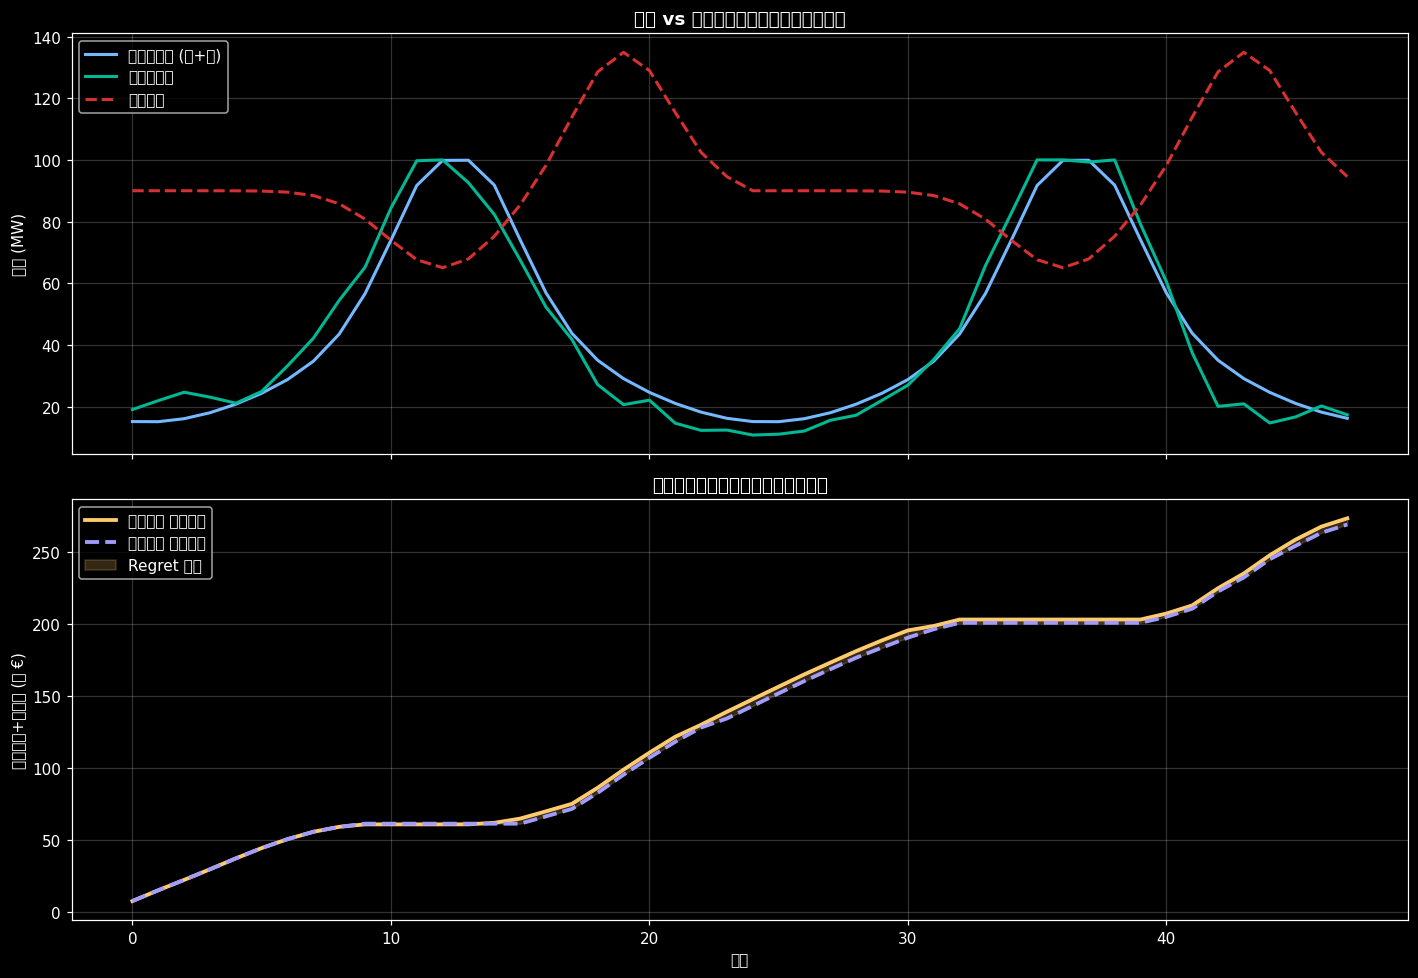

In [3]:
# ---- 可视化：预测vs真实 + 累计成本分叉 ----
cmc = cfg.coal_marginal_cost
cum_realized = np.cumsum(bt.realized_coal * cmc)
cum_perfect = np.cumsum(perfect.coal * cmc)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

ax1.plot(hours, wind_fc + solar_fc, color="#74b9ff", linewidth=2, label="预测可再生 (风+光)")
ax1.plot(hours, wind_actual + solar_actual, color="#00b894", linewidth=2, label="真实可再生")
ax1.plot(hours, demand, color="#d63031", linewidth=2, linestyle="--", label="负荷需求")
ax1.set_ylabel("功率 (MW)")
ax1.set_title("预测 vs 真实：引擎在信息不完美下决策", fontweight="bold")
ax1.legend()
ax1.grid(alpha=0.2)

ax2.plot(hours, cum_realized / 1e3, color="#fdcb6e", linewidth=2.5, label="滚动策略 累计成本")
ax2.plot(
    hours, cum_perfect / 1e3, color="#a29bfe", linewidth=2.5,
    linestyle="--", label="完美预测 累计成本",
)
ax2.fill_between(
    hours, cum_perfect / 1e3, cum_realized / 1e3,
    color="#fdcb6e", alpha=0.2, label="Regret 缺口",
)
ax2.set_xlabel("小时")
ax2.set_ylabel("累计燃料+碳成本 (千 €)")
ax2.set_title("累计成本分叉：预测误差的真实代价", fontweight="bold")
ax2.legend()
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()


In [4]:
# ---- 算力压榨：joblib 多核并行 vs 串行 ----
# 用一周(168h)长周期放大单任务计算量，让并行收益盖过 Windows 进程启动开销
import os

week = np.tile(np.arange(24), 7)
demand_w = 90 + 45 * np.exp(-((week - 19) ** 2) / 7) - 25 * np.exp(-((week - 12) ** 2) / 9)
solar_w = np.clip(60 * np.exp(-((week - 12.5) ** 2) / 10), 0, 55)
wind_w = np.clip(30 + 15 * np.cos(week / 24 * 2 * np.pi + 3.0), 0, 45)
capacities = np.arange(0, 301, 15, dtype=float)  # 21 个'平行宇宙'
print(f"CPU 核心数: {os.cpu_count()} | 扫描 {len(capacities)} 个容量 × 168h MILP")

# 预热 loky 进程池，剔除一次性进程启动开销（Windows 为 spawn 模式）
_ = scan_capacities(demand_w, wind_w, solar_w, capacities[:4], cfg, n_jobs=-1)

t0 = time.perf_counter()
df_ser = scan_capacities(demand_w, wind_w, solar_w, capacities, cfg, n_jobs=1)
t_ser = time.perf_counter() - t0

t0 = time.perf_counter()
df_par = scan_capacities(demand_w, wind_w, solar_w, capacities, cfg, n_jobs=-1)
t_par = time.perf_counter() - t0

print(f"串行耗时: {t_ser:.2f}s")
print(f"并行耗时: {t_par:.2f}s  ->  加速比 {t_ser / t_par:.2f}x")
df_par

CPU 核心数: 24 | 扫描 21 个容量 × 168h MILP


串行耗时: 3.70s
并行耗时: 2.06s  ->  加速比 1.80x


,capacity,total_cost,coal_energy,success
0,0.0,1.031027e+06,9263.882490,True
1,15.0,1.004696e+06,9024.510988,True
2,30.0,9.937237e+05,8924.760988,True
3,45.0,9.827512e+05,8825.010988,True
4,60.0,9.672485e+05,8684.077405,True
5,75.0,9.583229e+05,8602.935069,True
6,90.0,9.505050e+05,8531.863194,True
7,105.0,9.441998e+05,8474.543484,True
8,120.0,9.389878e+05,8427.162234,True
9,135.0,9.349921e+05,8390.837260,True
